# Excess heat factor: local time zone support

In [1]:
import earthkit.data as ekd
from earthkit.meteo.thermo import excess_heat
import earthkit.plots as ekp

import numpy as np

## ERA5: retrieve five days of hourly global 2 m temperatures

In [2]:
data = ekd.from_source("cds", dataset="reanalysis-era5-single-levels", request={
    "product_type": ["reanalysis"],
    "variable": ["2m_temperature"],
    "year": ["2025"],
    "month": ["07"],
    "day": [
        "01", "02", "03",
        "04", "05"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "grid": [0.5, 0.5],
    "data_format": "grib",
    "download_format": "unarchived"
})

In [3]:
t2m = data.to_xarray(time_dim_mode="valid_time")["2t"]
t2m

<xarray.DataArray '2t' (valid_time: 120, latitude: 361, longitude: 720)> Size: 250MB
[31190400 values with dtype=float64]
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 960B 2025-07-01 ... 2025-07-05T23...
  * latitude    (latitude) float64 3kB 90.0 89.5 89.0 88.5 ... -89.0 -89.5 -90.0
  * longitude   (longitude) float64 6kB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5
Attributes:
    standard_name:  unknown
    long_name:      2 metre temperature
    units:          K
    _earthkit:      {'message': b'GRIB\x00\x00l\x01\x00\x004\x80b\x91\xff\x80...

## Defining time zones

We assign one of 24 time zones with shifts from UTC+11 to UTC-12 to each longitude.
The UTC+0 time zone is centred at the prime meridian.

In [4]:
def local_time_shift_h(lons, lon0=0., width=np.timedelta64(1, "h")):
    n_timezones = np.timedelta64(24, "h") / width
    assert n_timezones == int(n_timezones)
    shift = np.round((lons - lon0) / (360 / n_timezones)) * width
    # Combine -12h and +12h zones (only keep -12h)
    shift_dt = (shift + np.timedelta64(12, "h")) % np.timedelta64(24, "h") - np.timedelta64(12, "h")
    return shift_dt.drop_attrs().rename("time_shift")

In [5]:
time_shift = local_time_shift_h(t2m["longitude"])

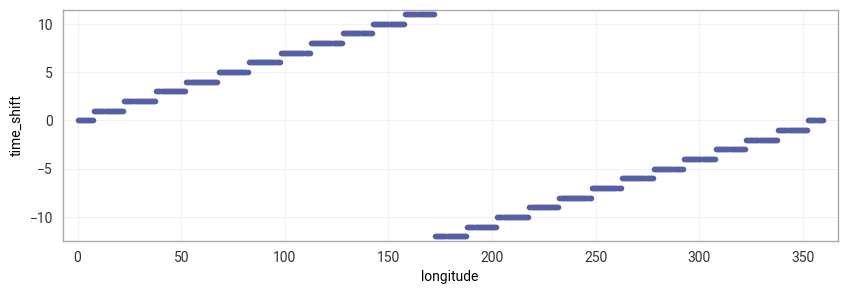

In [6]:
(time_shift / np.timedelta64(1, "h")).plot(figsize=(10, 3), marker=".", linestyle="none")

A two-dimensional spatial field of time shifts can also be supplied to the `daily_mean_temperature` function.
There is no support for daylight savings time.

## Daily mean temperature

In [7]:
dmt = excess_heat.daily_mean_temperature(t2m, day_start=9, time_shift=time_shift)

Plotting the daily mean temperature for the first day, we find that output is missing for timezones UTC+10 and UTC+11.
With the day starting at 9:00 local time, not enough data is available in these timezones to fill a full (local) day and daily mean temperature isn't computed.

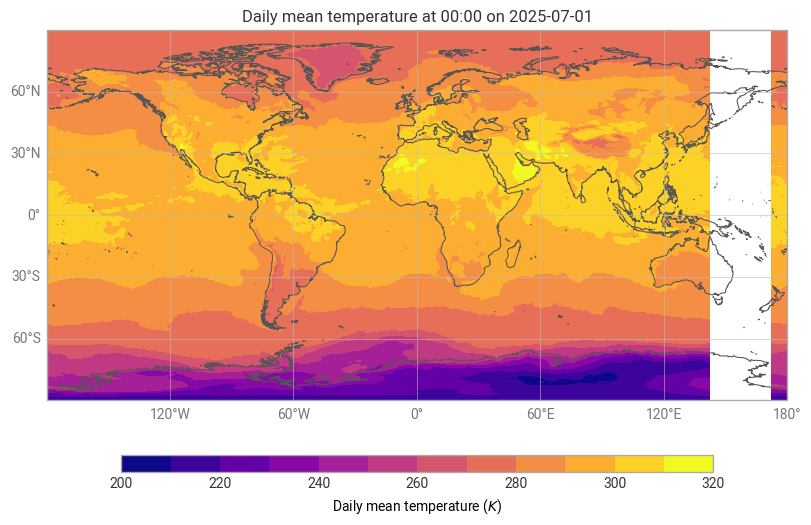

In [8]:
ekp.quickplot(dmt.isel(valid_time=0))

For the same reason, values are only available for for timezones UTC+9, UTC+10, UTC+11 on the last day:

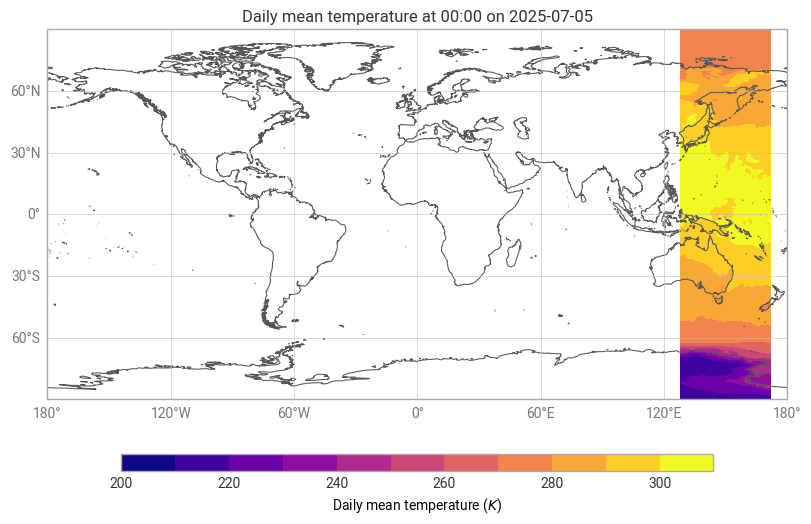

In [9]:
ekp.quickplot(dmt.isel(valid_time=-1))

The fields are complete for the intermediate timesteps, e.g.:

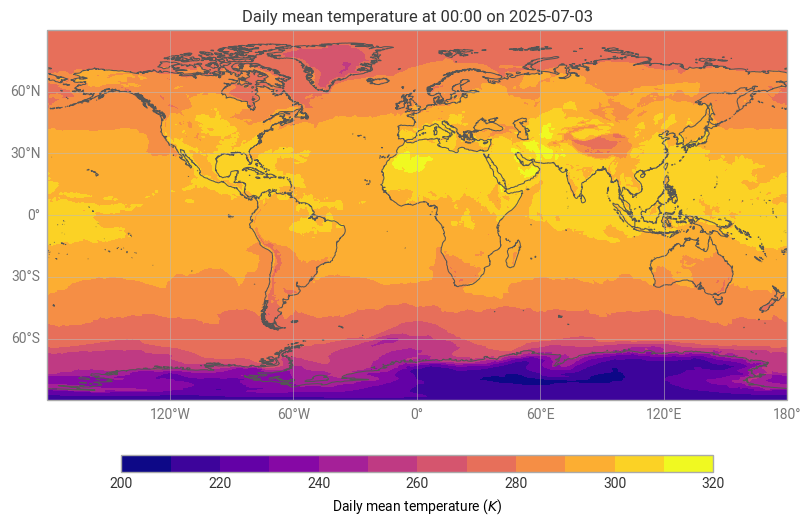

In [10]:
ekp.quickplot(dmt.isel(valid_time=2))